<a href="https://colab.research.google.com/github/NoaTal1996/Backbone-Graph/blob/main/src/Topic_Clustring_and_NER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Instalations and Imports

In [ ]:
try:
    # Running inside Google Colab → use !pip
    import google.colab
    in_google_colab = True
    print("Running in Colab → installing packages...")
    !pip install -q bertopic
    !pip install -q tweet-preprocessor
    !pip install -q spacy-entity-linker
    !pip install -q emoji
    !pip install sentence-transformers scikit-learn
    !pip install "transformers>=4.40.0" sentencepiece accelerate torch
except ImportError:
    # Not running in Colab
    in_google_colab = False
    pass

In [ ]:
import pandas as pd
import pyarrow  # ensures pandas can read/write parquet
import matplotlib.pyplot as plt

import re
import emoji

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

import spacy

from tqdm.auto import tqdm
from IPython.display import display

# Loading and Exporting
[Labeled Datasets for Research on Information Operations](https://zenodo.org/records/14189193)

## Load Data

In [ ]:
dataset_name = "Labeled_Datasets/Ecuador"  # folder path
file_name = f"Ecuador_part_5.gzip.parquet"  # file name

# if run local: put data in "../data/<dataset_name>/<file_name>"
# Recommended: working directory is: "Backbone-Graph/src"

In [ ]:
from pathlib import Path

# Google Colab
if in_google_colab:
    from google.colab import drive
    drive.mount('/content/drive')
    dataset_path = Path("/content/drive/Shareddrives/KeyBoostAuthor") / dataset_name / file_name
    print("Running inside Colab. Loading from Google Drive...")

# Cluster\Local
else:
    # Recommended: working directory is: "Backbone-Graph/src"
    dataset_path = Path("../data") / dataset_name / file_name
    print(f"Running on local/cluster.\nLoading data from: {dataset_path}")


# Load the parquet file
df = pd.read_parquet(dataset_path)

# for testing
# df = df.sample(n=1000, random_state=42).copy()

Running on local/cluster.
Loading data from: ../data/Labeled_Datasets/Ecuador/Ecuador_part_2.gzip.parquet


## Output Path


In [ ]:
from datetime import datetime
today = datetime.now().strftime("%Y_%m_%d")


dataset_path = Path(dataset_path)


if in_google_colab:
  output_folder_path = (dataset_path.parents[2] / "Labeled_Dataset_with_Topic_NER" / dataset_path.parent.name / dataset_path.name)
else:
  # working directory is: Backbone-Graph/src
  file_name_no_suffixes = file_name.split(".")[0]
  output_folder_path = Path("../results") / dataset_name / file_name_no_suffixes / today
  # Example: ""../results/Labeled_Datasets/Ecuador/Ecuador_part_4/2025_11_27"



output_folder_path.mkdir(parents=True, exist_ok=True) # Createst the output directory if needed

print(f"output_folder_path = {output_folder_path}")

output_folder_path = ../results/Labeled_Datasets/Ecuador/Ecuador_part_2/2025_11_30


In [ ]:
df.head()

,postid,post_text,application_name,post_language,in_reply_to_postid,in_reply_to_accountid,post_time,accountid,account_profile_description,follower_count,following_count,account_creation_date,is_repost,reposted_accountid,reposted_postid,hashtags,urls,account_mentions,is_control
50000,4ff6f0d9aa819f4b5b5b8f3f5e8d4f745e62e6cfd2,@be710a712dcc232048ef644125df6fa7382affd198 pro dime xke eso de bucear ??? Malo,e278f5ccf53957cccf9e97b2ae3fec72d5b892f850,es,189860bbd6438f7d7113ea779f006539b98bf71f95,be710a712dcc232048ef644125df6fa7382affd198,2012-04-16 14:13:23,b1922dfbce7bfa00f52a9701b2a421433d2ae9356a,"I just wanna live with U, in U and for U :$",551,642,2010-06-27,False,None,None,[],[],[be710a712dcc232048ef644125df6fa7382affd198],True
50001,e5261961d719351d425a650538dbab1e4615c2c6ea,@6de67df908dcba2c95a9d148024e8c1cb403f50a28 @be710a712dcc232048ef644125df6fa7382affd198 grax a los dos igualmente para ustedes :),e278f5ccf53957cccf9e97b2ae3fec72d5b892f850,es,7823e020263873584a77b68669d4331c11f6241789,6de67df908dcba2c95a9d148024e8c1cb403f50a28,2012-04-16 14:13:48,b1922dfbce7bfa00f52a9701b2a421433d2ae9356a,"I just wanna live with U, in U and for U :$",551,642,2010-06-27,False,None,None,[],[],"[6de67df908dcba2c95a9d148024e8c1cb403f50a28, be710a712dcc232048ef644125df6fa7382affd198]",True
50002,93ef41f56cd67934bc6dad5c20580fe6a148a82259,"No puede ser que me lo recuerde el precisamente hoy /""",e278f5ccf53957cccf9e97b2ae3fec72d5b892f850,es,None,None,2012-04-16 16:55:02,b1922dfbce7bfa00f52a9701b2a421433d2ae9356a,"I just wanna live with U, in U and for U :$",551,642,2010-06-27,False,None,None,[],[],[],True
50003,6dd27515e7da6fe4ebf6df79fa4389da98ce33b9ab,"""@f4e15e4b8f0f90c9e3125f43d5a75eff0af678a89a: Ahora si #muereLunesMartesMiercolesJuevesYViernes :)""",e278f5ccf53957cccf9e97b2ae3fec72d5b892f850,None,None,None,2012-04-16 17:08:00,71cc57155d061d447c2c65756c7dfd6873e403a097,🍃🧚‍♀️🧜‍♀️👑,3618,2055,2009-12-22,False,None,None,[muereLunesMartesMiercolesJuevesYViernes],[],[f4e15e4b8f0f90c9e3125f43d5a75eff0af678a89a],False
50004,cca666e7dacbaa0c031ffd84bbc8e95f698200280b,@fc5eb29ecbea7cd01646b2e9152453b772cc4b6db0 que bueno saberlo!! Tqmmmmm amiga...!,ea1dea0069b5115b3ecaf97fb95df660e1707fbf5c,es,0f4c9f1b17682b322b87d84dab0e644b5ca39d2717,b14d0ac084dc62adf5ba0fb7c43918202c055c392c,2012-04-16 18:14:09,cb6e693f7756b3900a654c52a4b33a010381aea900,"Periodista..Madre de Nicole. Un sueño,Henrique Capriles...! Marabina/Oriental.. Una fan enamorada.. Viviendo en Santiago",389,287,2010-10-02,False,None,None,[],[],[fc5eb29ecbea7cd01646b2e9152453b772cc4b6db0],True


# Dataset Statistics

In [ ]:
total_posts = len(df)
hashtag_posts = df[df['hashtags'].notna() & (df['hashtags'].str.len() > 0)]
mention_posts = df[df['account_mentions'].notna() & (df['account_mentions'].str.len() > 0)]
url_posts = df[df['urls'].notna() & (df['urls'].str.len() > 0)]

print(f"{'df shape:':<40} {df.shape}")
print(f"{'df posts with hashtags # shape:':<40} {hashtag_posts.shape}  ({len(hashtag_posts)/total_posts*100:.2f}%)")
print(f"{'df posts with account_mentions @ shape:':<40} {mention_posts.shape}  ({len(mention_posts)/total_posts*100:.2f}%)")
print(f"{'df posts with urls shape:':<40} {url_posts.shape}  ({len(url_posts)/total_posts*100:.2f}%)")


print()
print()

print(f"{'**collum name**':<30} **value type**")
for col in df.columns:
    # dtype_str = str(df[col].dtype)  # Convert dtype to string
    # get a sample non-null value if exists
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")


print()
print()
print(df['post_language'].value_counts())

df shape:                                (50000, 19)
df posts with hashtags # shape:          (16118, 19)  (32.24%)
df posts with account_mentions @ shape:  (29182, 19)  (58.36%)
df posts with urls shape:                (11241, 19)  (22.48%)


**collum name**                **value type**
postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | ndarray
urls                           | ndarray
account_mentions               | ndarray
is_control          

# Clean Text

In [ ]:
def clean_url(url_match):

    url = url_match.group(0)

    # 1. Remove protocol (http:// or https://)
    url = re.sub(r"https?://", "", url)
    url = re.sub(r"www\.", "", url)

    # 2. Remove query parameters (?x=1)
    url = url.split("?")[0]

    # 3. Split into components by "/"
    parts = url.split("/")

    # Domain (first part)
    domain = parts[0].replace(".", "_")  # twitter.com → twitter_com

    # First section (second part of the URL)
    if len(parts) > 1 and parts[1].strip() != "":
        section = parts[1].replace(".", "_")
        token = f" URL_{domain}_{section} "
    else:
        token = f" URL_{domain} "

    return token


In [ ]:
def clean_text(text: str) -> str:

    # lowercase
    text = str(text).lower()

    # URLs → domian + first section
    text = re.sub(r"(https?://\S+|www\.\S+)", clean_url, text)

    # Hashtags → HASHTAG_xxx
    text = re.sub(r"#(\w+)", r" HASHTAG_\1 ", text)

    # Mentions → MENTION_xxx
    text = re.sub(r"@(\w+)", r" MENTION_\1 ", text)

    # emoji → EMOJI_xxx
    text = emoji.demojize(text, delimiters=(" EMOJI_", " "))

    # Collapse spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
df["clean_post_text"] = df["post_text"].apply(clean_text)

## Remove Enttities Enteties

In [ ]:
import re
import pandas as pd

URL_RE = re.compile(r"(https?://\S+|www\.\S+)", flags=re.IGNORECASE)
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#(\w+)")
WHITESPACE_RE = re.compile(r"\s+")

def clean_enteties(text: str) -> str:
    """
    Lightly clean a social-media post while keeping it natural
    for machine translation.

    Operations:
    - Replace URLs with <URL>
    - Replace @username with <USER>
    - Turn #hashtag into 'hashtag' (drop the #)
    - Collapse repeated whitespace
    """
    if not isinstance(text, str):
        text = str(text)

    # lowercase
    text = str(text).lower()

    # 1. Normalize URLs
    text = URL_RE.sub("<URL>", text)

    # 2. Normalize mentions
    text = MENTION_RE.sub("<USER>", text)

    # 3. Normalize hashtags: "#Ecuador2025" -> "Ecuador2025"
    text = HASHTAG_RE.sub(r"\1", text)

    # 4. Collapse whitespace
    text = WHITESPACE_RE.sub(" ", text).strip()

    return text

In [ ]:
df["clean_text_no_enteties"] = df["post_text"].astype(str).apply(clean_enteties)

In [ ]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 2000)

df[["post_text", "clean_text_no_enteties"]].sample(n=20)

,post_text,clean_text_no_enteties
65006,"""@fa7dc162c1fc428ec81c3a556e2b09c7129d72c103: #90sBabyFollowTrain Follow Me ! Retweet &amp; ill follow back instantly ! but must follow back #HighSchoolFollowTrain""","""<USER>: 90sbabyfollowtrain follow me ! retweet &amp; ill follow back instantly ! but must follow back highschoolfollowtrain"""
98028,"Reportaje en Quito sobre seguridad en discotecas, respuesta de una tipa. En qué te fijas cuando llegas a una discoteca? -En un hombre- #plop","reportaje en quito sobre seguridad en discotecas, respuesta de una tipa. en qué te fijas cuando llegas a una discoteca? -en un hombre- plop"
51953,@9025ff5be83b644ec383bbf6da6601bf00823d1566 jajaja daleeeeee,<USER> jajaja daleeeeee
59972,DÓ RÉ MI FÁ FO DA SE. _I_,dó ré mi fá fo da se. _i_
57150,CFK pidió por la libertad y democracia de los pueblos. https://dcdbcaaf55b33f69f7fbe5bf98124ba7066a2d8d4f,cfk pidió por la libertad y democracia de los pueblos. <URL>
54857,Ruegan a @c3e3b3b546cf5da16b5ff822c98333781e2430b3e4 que diga que el #CopeteLeaks es falso: https://099e52071676e52829f782aea8a2ebe274232b7eda #MeEmputaQue no pueda.,ruegan a <USER> que diga que el copeteleaks es falso: <URL> meemputaque no pueda.
87122,"@ef3df8771a53b7fc1c3d90d24a3d4ea4218e7e7f04 @af5f6be1d32053a9b785676c01b29e7fa77737e99a @7ea7595d7feec44a63b3fa6b11714b04f6481c65ad y yo, no sabéis cuanto ojdhisfgdg.","<USER> <USER> <USER> y yo, no sabéis cuanto ojdhisfgdg."
84958,"FÃS BRASILEIROS = NÃO MORA PERTO DO IDOLO NAO CONVIVE COM ELE , MAIS INCOMPENSAÇÃO SOMOS OS MELHORES FÃS DO MUNDO","fãs brasileiros = não mora perto do idolo nao convive com ele , mais incompensação somos os melhores fãs do mundo"
58242,@a78966bf9c5d0e0a82dfbf96fba722498c7eefc905 @f42319a201250744b67c790a3c531681ff2c23dc6b arriba a su encuentro con la gente de #Samborondon https://7e05ff4863f8f1af8194810e063ca74a80d5d675d1,<USER> <USER> arriba a su encuentro con la gente de samborondon <URL>
96754,No se puede ser tan hermoso en la vidaa ♡_♡,no se puede ser tan hermoso en la vidaa ♡_♡


# Translation to English

In [ ]:
# map post_language codes to NLLB-200 language codes
# https://dl-translate.readthedocs.io/en/latest/available_languages/

def map_to_nllb_code(lang_code: str) -> str:
    """
    Map your dataset's post_language codes to NLLB-200 language codes.
    If not in mup return the same language code.
    Args:
        lang_code (str): Post language code.
    Returns:
        str: NLLB-200 language code.
    """
    nlln_mapping = {
    # Europe
    "en": "eng_Latn",   # English
    "es": "spa_Latn",   # Spanish
    "pt": "por_Latn",   # Portuguese
    "fr": "fra_Latn",   # French
    "de": "deu_Latn",   # German
    "it": "ita_Latn",   # Italian
    "nl": "nld_Latn",   # Dutch
    "ru": "rus_Cyrl",   # Russian
    "pl": "pol_Latn",   # Polish
    "sv": "swe_Latn",   # Swedish
    "ca": "cat_Latn",    # Catalan
    "cy": "cym_Latn",    # Welsh
    "et": "est_Latn",    # Estonian

    # Middle East
    "ar": "arb_Arab",   # Arabic (MSA)
    "he": "heb_Hebr",   # Hebrew
    "tr": "tur_Latn",   # Turkish
    "fa": "pes_Arab",   # Persian/Farsi

    # South Asia
    "hi": "hin_Deva",   # Hindi
    "ur": "urd_Arab",   # Urdu
    "bn": "ben_Beng",   # Bengali

    # East Asia
    "zh": "zho_Hans",   # Chinese Simplified
    "ja": "jpn_Jpan",   # Japanese
    "ko": "kor_Hang",   # Korean

    # Southeast Asia
    "vi": "vie_Latn",   # Vietnamese
    "id": "ind_Latn",   # Indonesian (modern code)
    "in": "ind_Latn",   # Indonesian (legacy ISO code)
    "tl": "tgl_Latn",   # Tagalog (Philippines)

    # Africa
    "sw": "swh_Latn",   # Swahili

    # Americas
    "qu": "quy_Latn",   # Quechua (Ayacucho)
}


    if lang_code in nlln_mapping:
        return nlln_mapping[lang_code]
    else:
        return lang_code

In [ ]:
df["post_language"] = df["post_language"].apply(map_to_nllb_code)

In [ ]:
# load models

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline

MODEL_NAME = "facebook/nllb-200-distilled-600M"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)
translation_pipeline = pipeline("translation", model=model, tokenizer=tokenizer, device=device, max_length=1000, batch_size=16)

Using device: cuda


Device set to use cuda


In [ ]:
from tqdm.auto import tqdm


def transformers_translator(
    df: pd.DataFrame,
    translation_pipe,
    text_col: str = "clean_text_no_enteties",
    lang_col: str = "post_language",
    out_col: str = "translated_post",
    target_lang: str = "eng_Latn",
    pivot_lang: str = "spa_Latn",
    backtranslate_same_lang: bool = True,
) -> pd.DataFrame:
    """
    Translate df[text_col] → target_lang using NLLB pipeline.

    If src_lang == target_lang and backtranslate_same_lang=True,
    perform back-translation: target_lang → pivot_lang → target_lang.

    Args:
        df (pd.DataFrame):
            Input DataFrame containing text and language labels.
        translation_pipe (transformers.pipeline):
            Pre-loaded translation pipeline (e.g., NLLB-200).
        text_col (str):
            Column containing original text.
        lang_col (str):
            Column containing language codes matching the pipeline
            (e.g., "spa_Latn", "eng_Latn").
        out_col (str):
            Column name for the translated output.
        target_lang (str):
            Target language code (default: "eng_Latn").
        pivot_lang (str):
            Pivot language code for back-translation (default: "spa_Latn").
        backtranslate_same_lang (bool):
            If True, back-translate rows where src_lang == target_lang.

    Returns:
        pd.DataFrame:
            A DataFrame with the same index as df and one column (out_col).
    """

    result_df = pd.DataFrame(index=df.index)
    result_df[out_col] = None

    # Iterate per language with progress bar
    for src_lang, group in tqdm(df.groupby(lang_col), desc="Translating by language"):

        # Build a list[str]
        texts = group[text_col].astype(str).tolist()

        # Keep the original indexes so we can assign back later
        indexes = group.index.to_list()

        translated = []  # empty means "no translation done"

        # Case 1: normal translation src_lang -> target_lang
        if src_lang != target_lang:
            print(f"{len(texts)} posts: {src_lang} → {target_lang}")
            outputs = translation_pipe(
                texts,
                src_lang=src_lang,
                tgt_lang=target_lang,
            )
            translated = [o["translation_text"] for o in outputs]

        # Case 2: back-translation target_lang -> pivot_lang -> target_lang
        if (src_lang == target_lang) and backtranslate_same_lang:
            print(f"{len(texts)} posts: {target_lang} → {pivot_lang} → {target_lang}")
            pivot_outputs = translation_pipe(
                texts,
                src_lang=target_lang,
                tgt_lang=pivot_lang,
            )
            pivot_texts = [o["translation_text"] for o in pivot_outputs]

            back_outputs = translation_pipe(
                pivot_texts,
                src_lang=pivot_lang,
                tgt_lang=target_lang,
            )
            translated = [o["translation_text"] for o in back_outputs]

        if translated:
            result_df.loc[indexes, out_col] = translated

    return result_df

In [ ]:
print(f"df shape: {df.shape}")
translated_df = transformers_translator(df, translation_pipeline)
df = df.drop(columns=["translated_post"], errors="ignore") # Drop the old column if exist
df = df.join(translated_df)

df shape: (50000, 21)


Translating by language:   0%|          | 0/37 [00:00<?, ?it/s]

281 posts: arb_Arab → eng_Latn
167 posts: cat_Latn → eng_Latn
11 posts: cs → eng_Latn
19 posts: cym_Latn → eng_Latn
9 posts: da → eng_Latn
34 posts: deu_Latn → eng_Latn
9455 posts: eng_Latn → spa_Latn → eng_Latn


Your input_length: 800 is bigger than 0.9 * max_length: 800. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_length: 800 is bigger than 0.9 * max_length: 800. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_length: 800 is bigger than 0.9 * max_length: 800. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_length: 800 is bigger than 0.9 * max_length: 800. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_length: 800 is bigger than 0.9 * max_length: 800. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_length: 800 is bigger than 0.9 * max_length: 800. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)
Your input_length: 800 is bigger than 0.9 * max_length: 800. You

87 posts: est_Latn → eng_Latn
32 posts: eu → eng_Latn
19 posts: fi → eng_Latn
505 posts: fra_Latn → eng_Latn
8 posts: hin_Deva → eng_Latn
77 posts: ht → eng_Latn
17 posts: hu → eng_Latn
625 posts: ind_Latn → eng_Latn
6 posts: is → eng_Latn
390 posts: ita_Latn → eng_Latn
1 posts: iw → eng_Latn
9 posts: jpn_Jpan → eng_Latn
15 posts: kor_Hang → eng_Latn
26 posts: lt → eng_Latn
13 posts: lv → eng_Latn
33 posts: nld_Latn → eng_Latn
14 posts: no → eng_Latn
44 posts: pol_Latn → eng_Latn
4344 posts: por_Latn → eng_Latn
22 posts: ro → eng_Latn
104 posts: rus_Cyrl → eng_Latn
8 posts: sl → eng_Latn
22914 posts: spa_Latn → eng_Latn
15 posts: swe_Latn → eng_Latn
182 posts: tgl_Latn → eng_Latn
16 posts: th → eng_Latn
37 posts: tur_Latn → eng_Latn
2 posts: uk → eng_Latn
1531 posts: und → eng_Latn
8 posts: vie_Latn → eng_Latn


In [ ]:
pd.set_option("display.width", 3000)
pd.set_option("display.max_colwidth", 1500)

df.sample(10)[["clean_text_no_enteties", "translated_post"]]

,clean_text_no_enteties,translated_post
96123,into the fold: why web design is more than one “rule” <URL> seo,In the fold: why web design is more than a rule <URL> seo
84984,<USER> <USER> boom boom boom ............ volcano erupt,It's been a long time since I've seen a volcano.
96238,13 new sessions added to ses new york 2013 <URL> seo,13 new sessions added to your new york 2013
52740,yo jugué con tazos.quesecaigalacedula,I played with cups. He's got it all figured out.
50984,tweet 10 000 :d mejoramiga *-* <USER>♥ :*,tweet 10 000:d improved *-* <USER>♥:*
58081,si una mujer dice que te odia eso significa que te ama. pero que eres un idiota.,"If a woman says she hates you, it means she loves you, but you're an idiot."
73709,"jajajajaja imy ☹ rt <USER>: gqq9k10zb838a5ipujm0bjrrxu2dhl7bdn+dpiadeam= jajajaja, okey, dejo de pensar esas cosas☺""",None
71631,cristhian benitez y sus vídeos favoritos.,Christian Benitez and his favorite videos.
61914,no se de donde sacas eso.,None
91633,<USER> yo ya tengo la entrada! pero no se q voy hacer. gente en roger?,"I already have the ticket, but I'm not going to make people roger."


# Remove Engllish Stopwords

In [ ]:
from nltk.corpus import stopwords
import nltk

In [ ]:
nltk.download('stopwords')

EXTRA_STOPWORDS = [
    'he', 'she', 'they', 'you', 'i', 'we', 'im', 'hes', 'shes', 'its', 'rt', 'amp', 're',
    'theyre', 'dont', 'doesnt', 'would', 'could', 'like', 'know', 'say', 'said', 'one',
    'look', 'looks', 'think', 'oh', 'yeah', 'guy', 'gonna', 'thing', 'someone', 'people',
    'get', 'got', 'thats', 'just', 'really', 'even', 'still', 'want', 'need', 'needs',
    'me', 'to', 'you', 'the', 'that', 'be', 'my', 'get', 'in', 'and',
     'rt', 'the', 'https', 'to', 'my', 'it', 'on', 'you', 'of', 'for', 'https', 'http', 'RT'
]
all_stopwords_english = set(stopwords.words('english') + EXTRA_STOPWORDS)

def remove_stopwords(text):
    return " ".join([w for w in text.lower().split() if w not in all_stopwords_english])


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/amitner/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
df["clean_post_text"] = df["clean_post_text"].apply(remove_stopwords)

In [ ]:
df[["post_text", "clean_post_text"]].head(20)

,post_text,clean_post_text
50000,@be710a712dcc232048ef644125df6fa7382affd198 pro dime xke eso de bucear ??? Malo,mention_be710a712dcc232048ef644125df6fa7382affd198 pro dime xke eso de bucear ??? malo
50001,@6de67df908dcba2c95a9d148024e8c1cb403f50a28 @be710a712dcc232048ef644125df6fa7382affd198 grax a los dos igualmente para ustedes :),mention_6de67df908dcba2c95a9d148024e8c1cb403f50a28 mention_be710a712dcc232048ef644125df6fa7382affd198 grax los dos igualmente para ustedes :)
50002,"No puede ser que me lo recuerde el precisamente hoy /""","puede ser que lo recuerde el precisamente hoy /"""
50003,"""@f4e15e4b8f0f90c9e3125f43d5a75eff0af678a89a: Ahora si #muereLunesMartesMiercolesJuevesYViernes :)""",""" mention_f4e15e4b8f0f90c9e3125f43d5a75eff0af678a89a : ahora si hashtag_muerelunesmartesmiercolesjuevesyviernes :)"""
50004,@fc5eb29ecbea7cd01646b2e9152453b772cc4b6db0 que bueno saberlo!! Tqmmmmm amiga...!,mention_fc5eb29ecbea7cd01646b2e9152453b772cc4b6db0 que bueno saberlo!! tqmmmmm amiga...!
50005,una vez me dije no me voy a enamorar Y me enamoré..,una vez dije voy enamorar enamoré..
50006,Jhdksksd.. Esa canción :')!,jhdksksd.. esa canción :')!
50007,& este amor que te tengo :3',& este amor que te tengo :3'
50008,"'Si hubo un culpable aquí, fui yo' :|","'si hubo un culpable aquí, fui yo' :|"
50009,"""Dime que no y lánzame un si camuflajeado"" jhfkds..","""dime que lánzame un si camuflajeado"" jhfkds.."


# English Topic Clustering

## Utils


In [ ]:
def make_topic_stats(df, topic_col_name):
    """
    Calculate per-topic post counts.

    Args:
        df (pd.DataFrame): Data with topics and 'is_control'.
        topic_col_name (str): Column name of topic labels.

    Returns:
        topic_stats (pd.DataFrame): Colums: [topic, total_count, io_Count, legitimate_posts, io_percent].
    """
    topic_stats = (
        df.groupby(topic_col_name)
          .agg(
              total_count=(topic_col_name, "count"),
              io_count=("is_control", lambda x: (~x).sum())
          )
          .reset_index()
    )
    topic_stats["legitimate_posts"] = topic_stats["total_count"] - topic_stats["io_count"]
    topic_stats["io_percent"] = topic_stats["io_count"] / topic_stats["total_count"] * 100
    return topic_stats

In [ ]:
def plot_topic_stats(topic_stats, topic_col_name, model_name, output_folder_path = ""):
    """
    Plot stacked IO vs legitimate post counts per topic.
    Saves the fig to output_path if provided.

    Args:
        topic_stats (pd.DataFrame): Output of make_topic_stats().
        topic_col_name (str): Topic column to plot.
        output_folder_path (str): Path to *folder* save the plot.

    Returns:
        None
    """
    topics = topic_stats[topic_col_name]
    io_count = topic_stats["io_count"]
    legitimate_count = topic_stats["legitimate_posts"]
    io_percent = topic_stats["io_percent"]

    plt.figure(figsize=(12, 6))

    # 🔴 Bottom: IO posts
    plt.bar(topics, io_count, label="IO posts", color="red")

    # 🔵 Top: Non-IO posts stacked above IO
    plt.bar(topics, legitimate_count, bottom=io_count, label="Non-IO posts")

    # Add IO percentage text
    ax = plt.gca()
    for x, io, legit, pct in zip(topics, io_count, legitimate_count, io_percent):
        total_height = io + legit
        ax.text(
            x,
            total_height + 1,              # slightly above the bar
            f"{pct:.1f}%",                 # format like 23.5%
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    plt.title(f"Post Count per Topic ({model_name})")
    plt.xlabel("Topic ID")
    plt.ylabel("Number of Posts")
    plt.text(0.98, 0.82, f"Total posts: {topic_stats['total_count'].sum()}", ha="right", va="bottom", transform=plt.gca().transAxes)
    plt.xticks(topics)
    plt.grid(axis="y")
    plt.legend()
    plt.tight_layout()


    if output_folder_path:
        plot_file_path = output_folder_path / (f"{model_name}_topic_clustering.png")
        plt.savefig(plot_file_path, dpi=300)
        print(f"plot is saved to {plot_file_path}")

    plt.show()

In [ ]:
clean_posts_text_lst = df["clean_post_text"].to_list()

In [ ]:
from sklearn.preprocessing import normalize

# Load model
model = SentenceTransformer("digio/Twitter4SSE")

# Embeddings
embeddings = model.encode(clean_posts_text_lst, show_progress_bar=True)
embeddings = normalize(embeddings)

No sentence-transformers model found with name digio/Twitter4SSE. Creating a new one with mean pooling.


Batches:   0%|          | 0/1563 [00:00<?, ?it/s]

## BERTopic

In [ ]:
def english_BERTopic_modeling(posts_text_lst, embeddings, output_folder_path= "", min_topic_size=400):
    """
    Run BERTopic using precomputed embeddings.

    Args:
        posts_text_lst (list[str]): English text posts.
        embeddings (np.ndarray): Precomputed embeddings aligned with the posts.
        min_topic_size (int): Minimum cluster size.

    Returns:
        topics, probs, topic_model
    """
    topic_model = BERTopic(
        language="english",
        min_topic_size=min_topic_size,
        verbose=True # show logs
    )

    topics, probs = topic_model.fit_transform(posts_text_lst, embeddings)

    # save model to folder
    if output_folder_path:
        topic_model.save(output_folder_path / "BERTopic_model")
        print(f"BERTopic model is saved to {output_folder_path}")

    return topics, probs, topic_model


In [ ]:
BERTopic_topic, BERT_probs, BERTopic_model = english_BERTopic_modeling(clean_posts_text_lst, embeddings, output_folder_path)

df["BERTopic_topic"] = BERTopic_topic

BERTopic_model.get_topic_info()

2025-11-30 12:18:32,377 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.
2025-11-30 12:18:32,392 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


BERTopic model is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_2/2025_11_30


2025-11-30 12:19:17,221 - BERTopic - Dimensionality - Completed ✓
2025-11-30 12:19:17,223 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-30 12:19:25,628 - BERTopic - Cluster - Completed ✓
2025-11-30 12:19:25,635 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-30 12:19:26,038 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,5006,-1_hashtagmiequipolan_hashtagrt_emojicheckmark_de,"[hashtagmiequipolan, hashtagrt, emojicheckmark, de, follow, mentionc0748824909a95d593732a87010cef84d846092cb4, en, que, la, sigue]","[emoji_check_mark ｒｅｔｗｅｅｔ hashtag_gnation ""the fastest gain team twitter"" 100 emoji_check_mark day 200 emoji_check_mark day ⓡⓔⓣⓦⓔⓔⓣ ┴═╦╕47 emoji_trade_mark hashtag_gnation killing ur tl mention_bbbe9b92899a2248b6cb272e72c62358fffb62f140, emoji_check_mark ｒｅｔｗｅｅｔ hashtag_gnation ""the fastest gain team twitter"" 100 emoji_check_mark day 200 emoji_check_mark day ⓡⓔⓣⓦⓔⓔⓣ ┴═╦╕47 emoji_trade_mark hashtag_gnation killing ur tl mention_bf387f6851a063b6a39a3e9b007b3e92ffdaa317f5, emoji_check_mark ｒｅｔｗｅｅｔ hashtag_gnation ""the fastest gain team twitter"" 100 emoji_check_mark day 200 emoji_check_mark day ⓡⓔⓣⓦⓔⓔⓣ ┴═╦╕47 emoji_trade_mark hashtag_gnation killing ur tl mention_85dc9544b99075ddbc7610dbe814806fd0850e34ac]"
1,0,25570,0_de_la_en_el,"[de, la, en, el, que, por, es, los, se, con]","[cuando ya piensas en la mention_728078d53dfd8c6451cc62528c3e3861db03f77408 es que hay un descontento en tu trabajo hashtag_fact cc mention_4d5ea683541202512ee270ed8a99fc697d756e5976, la ""sonrisa"" de hashtag_lasso la creyeron en sus 25 años en la banca, xq siempre la guardó en una oficina! más falso que mention_acc45ee2402663f2b8e401bb6daca9d89a52609d1d !!!, ""no señor bucaram, hashtag_rafaelpactóconmigo "" con los niños de la patria para una mejor educación. url_9937255861c507d0b85e270e139d338c8907dc59c8]"
2,1,8616,1_que_de_la_el,"[que, de, la, el, en, es, se, lo, te, un]","[te sorprendería saber todo lo que yo se., nunca te arrepientas de la gente que entrado en tu vida, porque son ell mention_s los que te han convertido en lo que eres hoy., que querías que? que querías que? que saque esto? que querías que? que querías que? que querías que mierda!!! hijos de puta! akdakhfkladh]"
3,2,5233,2_emojiheartsuit_emojifrowningface_amp_emojismilingface,"[emojiheartsuit, emojifrowningface, amp, emojismilingface, love, me, never, go, hashtagrt, you]","[&amp; good kick ass, tell girl love emoji_heart_suit, love emoji_frowning_face]"
4,3,2891,3_de_la_en_el,"[de, la, en, el, que, los, un, con, es, se]","[por el campeón hashtag_miequipolan, hashtag_ecuador en oración por canadá, hashtag_fuerzascanadá, vamos con todo es en la hashtag_farandula lo que en carne propia es en la hashtag_comunidad hashtag_matematicasimple]"
5,4,1754,4_eu_no_vou_pra,"[eu, no, vou, pra, que, com, de, um, da, hashtagrt]","[quando chegar lá na casa da minha vó eu faço hashtag_horóscopo1d porque tô com preguiça de facts hoje '-', please, não deem unfollow com esses link's que eu vou postar '-' é que eu tô em outro usuário, daí já sabe né k, ""filha, voce tem que seguir seu sonho.."" ""mae, eu ja sigo luan faz tempo, foi pra isso que eu criei um twitter""]"
6,5,478,5_emojiheartsuit_de_amiga_hashtaguio,"[emojiheartsuit, de, amiga, hashtaguio, te, amo, mi, siganla, mention836da1d15f3c53d3ffd5e09be7d338815d5cab9397, es]","[siganla por favor mention_836da1d15f3c53d3ffd5e09be7d338815d5cab9397 es de una amiga, pide followback!!! 5, siganla por favor mention_836da1d15f3c53d3ffd5e09be7d338815d5cab9397 es de una amiga, pide followback!!! 1, siganla por favor mention_836da1d15f3c53d3ffd5e09be7d338815d5cab9397 es de una amiga, pide followback!!! 3]"
7,6,452,6_barcelona_el_de_gol,"[barcelona, el, de, gol, en, del, hashtagper, la, vs, hashtagecuador]","[vamos barcelona de mi emoji_heart_suit, gol del hijo de barcelona: emelec, ¸„ø¤º°¨un¨°º¤ø„¸solo¸„ø¤º°¨ídolo¨°º¤ø„tiene¸„ø¤º°el¨°º¤ø„¸ecuador¸„ø¤º°barcelona°º¤ø„¸campeón¸„ø¤º°¨barcelona¨°º¤ø„¸ ...]"


plot is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_2/2025_11_30/BERTopic_topic_clustering.png


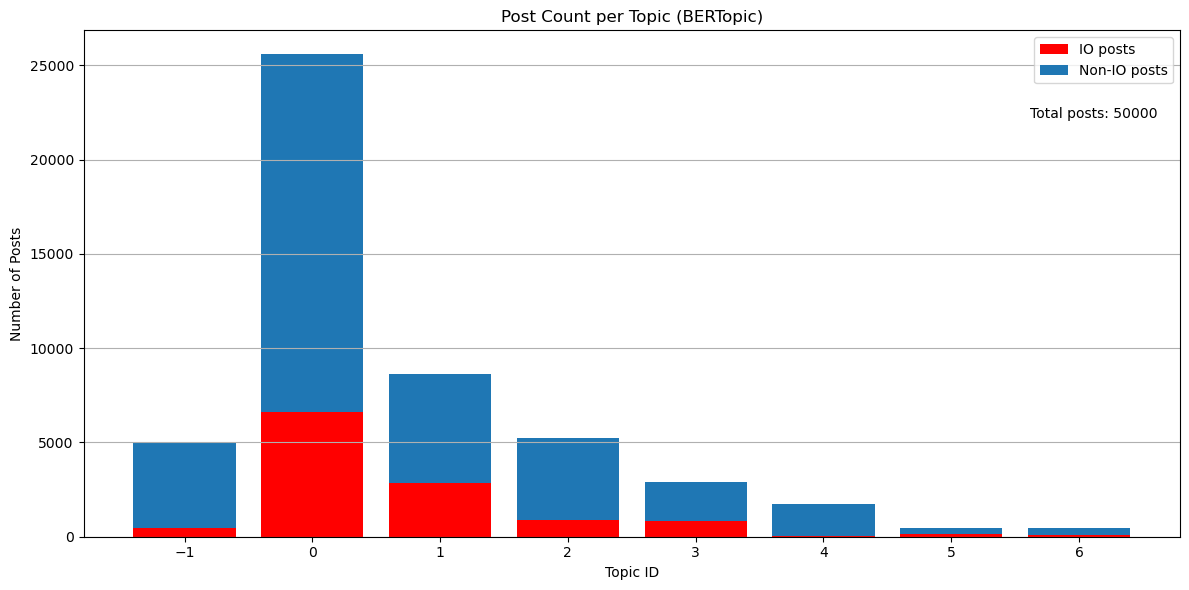

In [ ]:
topic_col_name = "BERTopic_topic"
BERT_topic_stats = make_topic_stats(df, topic_col_name)
plot_topic_stats(BERT_topic_stats, topic_col_name, "BERTopic", output_folder_path)

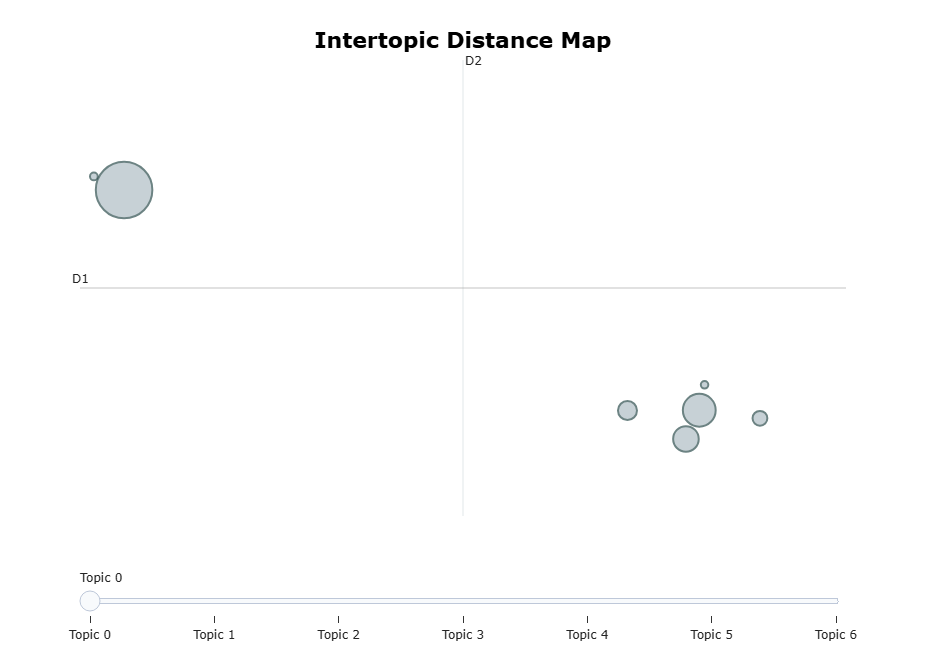

In [ ]:
from IPython.display import display

try:
    fig = BERTopic_model.visualize_topics(custom_labels=True)
    display(fig)   # show it
except Exception as e:
    print("Not enough topics for visualization")
    print("Error:", e)

## K-Means

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def auto_kmeans_topics(embeddings, k_min=4, k_max=40, step = 2):
    best_k = None
    best_score = -1
    best_labels = None

    for k in range(k_min, k_max + 1, step):
        print(f"Trying k={k}")
        km = KMeans(n_clusters=k, random_state=42, n_init="auto")
        labels = km.fit_predict(embeddings)
        score = silhouette_score(embeddings, labels)

        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

    return best_labels, best_k

In [ ]:
# Add to df
labels, best_k = auto_kmeans_topics(embeddings)
df["K_Means_topic"] = labels
print(f"Best k: {best_k}")
df.head()

Best k: 4


,postid,post_text,application_name,post_language,in_reply_to_postid,in_reply_to_accountid,post_time,accountid,account_profile_description,follower_count,...,reposted_postid,hashtags,urls,account_mentions,is_control,clean_post_text,clean_text_no_enteties,translated_post,BERTopic_topic,K_Means_topic
50000,4ff6f0d9aa819f4b5b5b8f3f5e8d4f745e62e6cfd2,@be710a712dcc232048ef644125df6fa7382affd198 pro dime xke eso de bucear ??? Malo,e278f5ccf53957cccf9e97b2ae3fec72d5b892f850,spa_Latn,189860bbd6438f7d7113ea779f006539b98bf71f95,be710a712dcc232048ef644125df6fa7382affd198,2012-04-16 14:13:23,b1922dfbce7bfa00f52a9701b2a421433d2ae9356a,"I just wanna live with U, in U and for U :$",551,...,None,[],[],[be710a712dcc232048ef644125df6fa7382affd198],True,mention_be710a712dcc232048ef644125df6fa7382affd198 pro dime xke eso de bucear ??? malo,<USER> pro dime xke eso de bucear ??? malo,<USER> pro tell me xke that about diving ??? bad,0,0
50001,e5261961d719351d425a650538dbab1e4615c2c6ea,@6de67df908dcba2c95a9d148024e8c1cb403f50a28 @be710a712dcc232048ef644125df6fa7382affd198 grax a los dos igualmente para ustedes :),e278f5ccf53957cccf9e97b2ae3fec72d5b892f850,spa_Latn,7823e020263873584a77b68669d4331c11f6241789,6de67df908dcba2c95a9d148024e8c1cb403f50a28,2012-04-16 14:13:48,b1922dfbce7bfa00f52a9701b2a421433d2ae9356a,"I just wanna live with U, in U and for U :$",551,...,None,[],[],"[6de67df908dcba2c95a9d148024e8c1cb403f50a28, be710a712dcc232048ef644125df6fa7382affd198]",True,mention_6de67df908dcba2c95a9d148024e8c1cb403f50a28 mention_be710a712dcc232048ef644125df6fa7382affd198 grax los dos igualmente para ustedes :),<USER> <USER> grax a los dos igualmente para ustedes :),<USER> <USER> grax both equally for you :),0,0
50002,93ef41f56cd67934bc6dad5c20580fe6a148a82259,"No puede ser que me lo recuerde el precisamente hoy /""",e278f5ccf53957cccf9e97b2ae3fec72d5b892f850,spa_Latn,None,None,2012-04-16 16:55:02,b1922dfbce7bfa00f52a9701b2a421433d2ae9356a,"I just wanna live with U, in U and for U :$",551,...,None,[],[],[],True,"puede ser que lo recuerde el precisamente hoy /""","no puede ser que me lo recuerde el precisamente hoy /""","It can't be that I remember it precisely today/""",1,1
50003,6dd27515e7da6fe4ebf6df79fa4389da98ce33b9ab,"""@f4e15e4b8f0f90c9e3125f43d5a75eff0af678a89a: Ahora si #muereLunesMartesMiercolesJuevesYViernes :)""",e278f5ccf53957cccf9e97b2ae3fec72d5b892f850,None,None,None,2012-04-16 17:08:00,71cc57155d061d447c2c65756c7dfd6873e403a097,🍃🧚‍♀️🧜‍♀️👑,3618,...,None,[muereLunesMartesMiercolesJuevesYViernes],[],[f4e15e4b8f0f90c9e3125f43d5a75eff0af678a89a],False,""" mention_f4e15e4b8f0f90c9e3125f43d5a75eff0af678a89a : ahora si hashtag_muerelunesmartesmiercolesjuevesyviernes :)""","""<USER>: ahora si muerelunesmartesmiercolesjuevesyviernes :)""",None,0,0
50004,cca666e7dacbaa0c031ffd84bbc8e95f698200280b,@fc5eb29ecbea7cd01646b2e9152453b772cc4b6db0 que bueno saberlo!! Tqmmmmm amiga...!,ea1dea0069b5115b3ecaf97fb95df660e1707fbf5c,spa_Latn,0f4c9f1b17682b322b87d84dab0e644b5ca39d2717,b14d0ac084dc62adf5ba0fb7c43918202c055c392c,2012-04-16 18:14:09,cb6e693f7756b3900a654c52a4b33a010381aea900,"Periodista..Madre de Nicole. Un sueño,Henrique Capriles...! Marabina/Oriental.. Una fan enamorada.. Viviendo en Santiago",389,...,None,[],[],[fc5eb29ecbea7cd01646b2e9152453b772cc4b6db0],True,mention_fc5eb29ecbea7cd01646b2e9152453b772cc4b6db0 que bueno saberlo!! tqmmmmm amiga...!,<USER> que bueno saberlo!! tqmmmmm amiga...!,It's good to know! tqmmmmm friend...!,0,0


plot is saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_2/2025_11_30/K-Means_topic_clustering.png


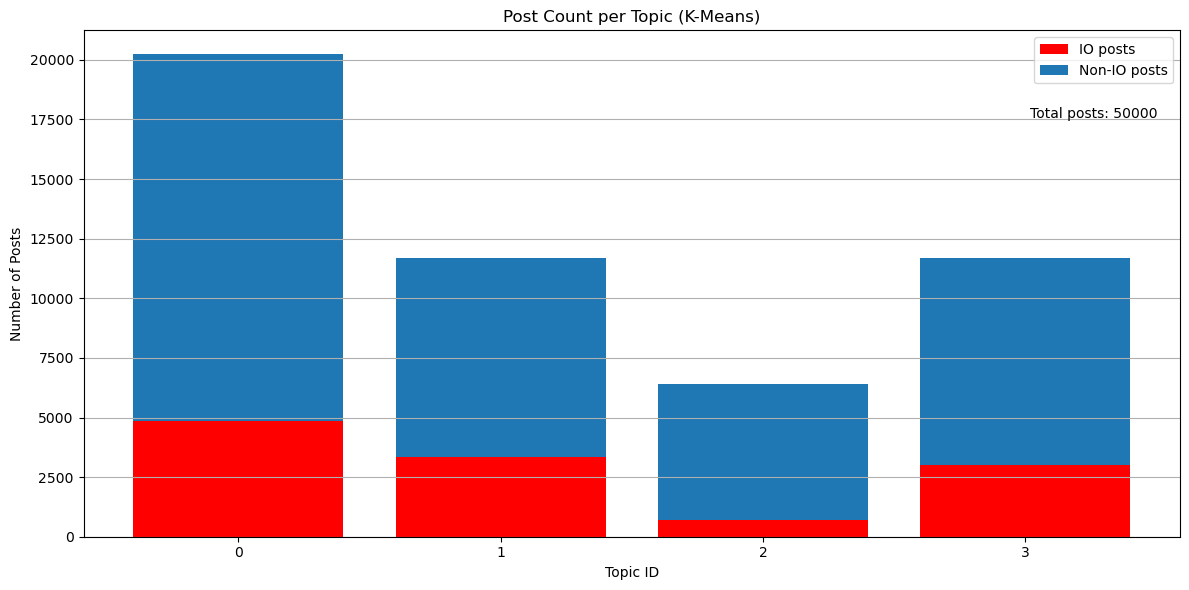

In [ ]:
topic_col_name = "K_Means_topic"
topic_stats = make_topic_stats(df, topic_col_name)
plot_topic_stats(topic_stats, topic_col_name, "K-Means", output_folder_path)

# Named Entity Recognition (NER)

In [ ]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

# Load model ONCE
tokenizer = AutoTokenizer.from_pretrained("TweebankNLP/bertweet-tb2_wnut17-ner")
ner_model = AutoModelForTokenClassification.from_pretrained("TweebankNLP/bertweet-tb2_wnut17-ner")

ner_pipeline = pipeline(
    "token-classification",
    model=ner_model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)


def extract_ner_entities(posts_lst: list):
    """
    Runs NER in batches on a list of text posts.

    Args:
          posts_lst (list): List of strings (cleaned posts).
    Returns
    -------
    all_entities (list[list[str]]): For each post: a list of extracted entity words.
    """

    ner_outputs = ner_pipeline(posts_lst)
    all_entities = []
    for post_output in ner_outputs:
        words = [ent["word"] for ent in post_output]
        all_entities.append(words)

    return all_entities

Device set to use cuda:0


In [ ]:
# Apply ONCE, no pandas apply, in order to utilize batches.
df["ner_entities"] = extract_ner_entities(df["clean_post_text"].to_list())

In [ ]:
df.loc[df["ner_entities"].astype(bool), ["clean_post_text", "ner_entities"]].head()

,clean_post_text,ner_entities
50024,"salir comer, ir al cine, convencerme que la soledad hace mejor..",[sol@@]
50038,""" mention_a0a1806a6ccc871c1def5eda741553adf4c3407ff2 : debe aclararse prácticas salvajes al interior del ejército, señala fernando gonzález url_a36a69a9e1c2b9726116821bb8d6d4981c49017cbd vía mention_545f1706fc0edbbbb8a9a8b9bbdb6bb55a63fc99b9 ""","[se@@, fernando gonzález]"
50053,puedo escuchar 'thank loving me' comienzo llorar :'|,[loving me@@]
50073,"empezó el aguacero en la alborada, norte de guayaquil.","[albor@@, guayaqu@@]"
50088,"""nos pasamos la vida esperando que pase algo lo único que pasa es la vida."" hashtag_bobmarleyquotes",[bobmarley@@]


# Entities Statistics

In [ ]:
import pandas as pd

def compute_entity_topic_matrix(df, entity_col, topic_col="topic_id", is_control_col="is_control", output_folder_path=None):
    """
    Create a df where values = number of times the entity appears in each topic.

    Args:
        df (pd.DataFrame):
            DataFrame containing posts, entity lists, topic labels and is_control.
        entity_col (str):
            Column containing a list of entities per post.
        topic_col (str):
            Column containing topic labels.
        is_control_col (str):
            Boolean column: True = legitimate, False = IO.

    Returns:
        entity_topic_counts (pd.DataFrame):
            Columns:
                [entity, total_count, io_percent, topic_ids = 1, 2, 3...]
    """

    # 1) Explode entity lists → one row per (entity, topic, is_control)
    df_exp = (
        df[[entity_col, topic_col, is_control_col]]
        .explode(entity_col)
        .dropna(subset=[entity_col])
        .copy()
    )

    # 2) Aggregate counts per entity (overall)
    entity_stats = (
        df_exp.groupby(entity_col)
              .agg(
                  total_count=(entity_col, "count"),
                  io_count=(is_control_col, lambda x: (~x).sum()),  # False = IO
              )
              .reset_index()
    )
    entity_stats["io_percent"] = 100 * entity_stats["io_count"] / entity_stats["total_count"]
    entity_stats = entity_stats[[entity_col, "total_count", "io_percent"]]

    # 3) Count occurrences per (entity, topic)
    entity_topic_counts = (
        df_exp.groupby([entity_col, topic_col])
              .size()
              .reset_index(name="count")
    )

    # 4) Pivot to wide format (entity rows × topic columns)
    entity_topic_counts = (
        entity_topic_counts
        .pivot_table(
            index=entity_col,
            columns=topic_col,
            values="count",
            fill_value=0
        )
        .sort_index(axis=1)   # ensure topic columns sorted: 0,1,2,...
        .reset_index()
    )

    # 5) Merge total_count + IO stats
    entity_topic_counts = entity_stats.merge(entity_topic_counts, on=entity_col, how="left")

    # 6) Sort by total_count (descending)
    entity_topic_counts = entity_topic_counts.sort_values("total_count", ascending=False)

    # 7) Save if path provided
    if output_folder_path:
        output_path = Path(output_folder_path) / f"entity_topic_matrix.gzip.parquet"
        df.to_parquet(output_path, index=False, compression="gzip")
        print(f"Saved to {output_path}")

    return entity_topic_counts

In [ ]:
import matplotlib.pyplot as plt

def plot_entity_topic_distribution(entity, entity_topic_counts, entity_col, clustering_model="", output_folder_path=None):
    """
    Plot how many times a given entity appears in each topic.
    """

    # Extract row for chosen entity
    row = entity_topic_counts.loc[entity_topic_counts[entity_col] == entity].iloc[0]

    # Keep only topic columns (numeric topic IDs)
    topic_cols = [c for c in entity_topic_counts.columns if isinstance(c, int)]
    counts = row[topic_cols]       # Series like [topic_id → count]

    # --- Plot ---
    plt.figure(figsize=(12, 5))
    plt.bar(topic_cols, counts)

    plt.title(f"Topic Distribution for Entity: '{entity}'")
    plt.xlabel("Topic ID")
    plt.ylabel("Count of occurrences")
    plt.xticks(topic_cols)
    plt.grid(axis="y")
    plt.ylim(0, counts.max()* 1.15 ) # y-axis height: 15% padding above the tallest bar
    # Add metadata note (top-right)
    plt.text(
        0.98, 0.92,
        f"clustering model: {clustering_model}\nEntities col: {entity_col}",
        ha="right",
        va="top",
        transform=plt.gca().transAxes
    )

    # plot
    plt.tight_layout()

    # Save if path provided
    if output_folder_path:
        plot_path = output_folder_path / f"{entity}_topic_distribution.png"
        plt.savefig(plot_path, dpi=300)
        print(f"Saved figure to: {plot_path}")

    plt.show()

,ner_entities,total_count,io_percent,0,1,2,3
2048,ecuador,548,28.467153,54.0,52.0,3.0,439.0
746,barcelona,387,18.087855,144.0,47.0,0.0,196.0
7135,twitter,323,12.074303,146.0,49.0,38.0,90.0
2864,guayaqu@@,304,34.539474,84.0,25.0,0.0,195.0
2386,fb,189,2.645503,90.0,6.0,68.0,25.0


Saved to ../results/Labeled_Datasets/Ecuador/Ecuador_part_2/2025_11_30/entity_twitter_topic_distribution.png


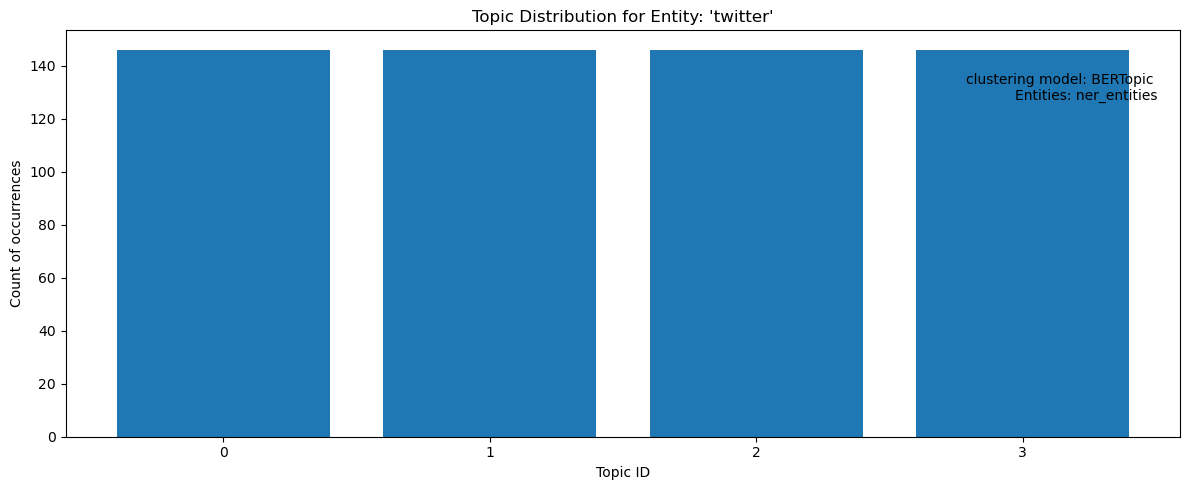

In [ ]:
entity_col_name = "ner_entities"
topic_col = "BERTopic_topic"

entity_topic_matrix = compute_entity_topic_matrix(df, entity_col_name, topic_col)
display(BERT_entity_topic_matrix.head())

entity = BERT_entity_topic_matrix[entity_col_name].iloc[0]   # first entity
plot_entity_topic_distribution(entity=entity, entity_topic_counts=BERT_entity_topic_matrix, entity_col=entity_col_name, clustering_model = topic_col, output_folder_path=output_folder_path)

# Save to parquet

In [ ]:
# print dataset statistics
for col in df.columns:
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")

postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | ndarray
urls                           | ndarray
account_mentions               | ndarray
is_control                     | bool
clean_post_text                | str
clean_text_no_enteties         | str
translated_post                | str
BERTopic_topic                 | int64
K_Means_topic                  | int32
ner_entities                   | list


In [ ]:
df_output_path = output_folder_path / f"Topic_Ner_{file_name}"

df.to_parquet(df_output_path, index=False, compression="gzip")
print("df is saved to:", df_output_path)

df is saved to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_2/2025_11_30/Topic_Ner_Ecuador_part_2.gzip.parquet
